Please upload your 'china_gdp.csv' file:


Saving china_gdp.csv to china_gdp.csv

       FINAL PROJECT SUMMARY
Data Points Found:     63
Sigmoid R² Accuracy:   0.8183
MLP Neural Net R²:     0.9919
MLP Iterations:        546
Mean Squared Error:    0.000696


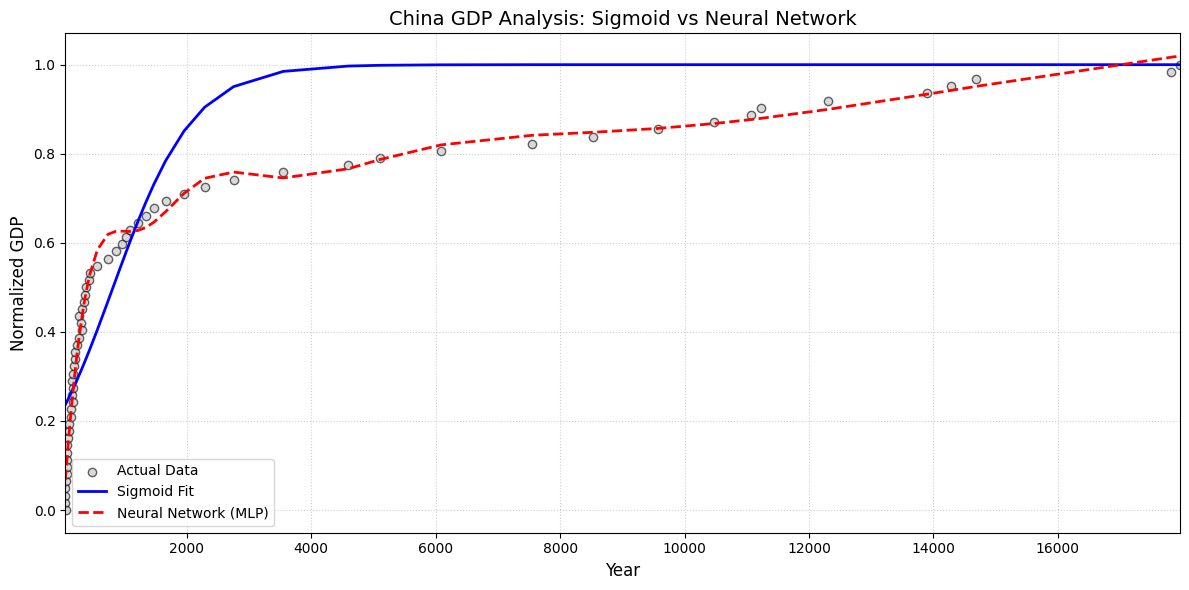


✅ Files saved: 'sigmoid_weights.npy' and 'china_gdp_mlp_model.pkl'


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from google.colab import files
import io
import joblib

# ==========================================
# 1. DATA UPLOAD SECTION
# ==========================================
print("Please upload your 'china_gdp.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# ==========================================
# 2. BRUTE FORCE DATA CLEANING
# ==========================================
def clean_to_numeric(series):
    # Removes non-numeric characters and converts to float
    return pd.to_numeric(series.astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# Auto-detecting the best columns for Year and GDP
numeric_df = df.apply(clean_to_numeric)
valid_cols = numeric_df.count().sort_values(ascending=False).index

col_a = numeric_df[valid_cols[0]]
col_b = numeric_df[valid_cols[1]]

# Assigning smaller values to Year and larger to GDP
if col_a.mean() < col_b.mean():
    x_raw, y_raw = col_a.values, col_b.values
else:
    x_raw, y_raw = col_b.values, col_a.values

# Remove missing values and sort
mask = ~np.isnan(x_raw) & ~np.isnan(y_raw)
x_raw, y_raw = x_raw[mask], y_raw[mask]
idx = np.argsort(x_raw)
x_raw, y_raw = x_raw[idx], y_raw[idx]

# ==========================================
# 3. NORMALIZATION
# ==========================================
xdata = (x_raw - x_raw.min()) / (x_raw.max() - x_raw.min())
ydata = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())

# ==========================================
# 4. CLASSICAL MODEL: SIGMOID REGRESSION
# ==========================================
def sigmoid(x, Beta_1, Beta_2):
    return 1 / (1 + np.exp(-Beta_1 * (x - Beta_2)))

popt, _ = curve_fit(sigmoid, xdata, ydata, p0=[10, 0.5])
y_pred_sigmoid = sigmoid(xdata, *popt)

# ==========================================
# 5. MODERN MODEL: NEURAL NETWORK (MLP)
# ==========================================
mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=5000,           # Increased to allow full convergence
    activation='logistic',    # Better fit for the "S" curve of GDP data
    solver='lbfgs',          # Optimized for smaller datasets (n=63)
    random_state=42
)

# Keep the following lines as they are to train and predict
mlp.fit(xdata.reshape(-1, 1), ydata)
y_pred_mlp = mlp.predict(xdata.reshape(-1, 1))

# ==========================================
# 6. PERFORMANCE SUMMARY
# ==========================================
print("\n" + "="*35)
print("       FINAL PROJECT SUMMARY")
print("="*35)
print(f"Data Points Found:     {len(x_raw)}")
print(f"Sigmoid R² Accuracy:   {r2_score(ydata, y_pred_sigmoid):.4f}")
print(f"MLP Neural Net R²:     {r2_score(ydata, y_pred_mlp):.4f}")
print(f"MLP Iterations:        {mlp.n_iter_}")
print(f"Mean Squared Error:    {mean_squared_error(ydata, y_pred_mlp):.6f}")
print("="*35)

# ==========================================
# 7. FINAL POLISHED VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 6))
plt.scatter(x_raw, ydata, color='silver', label='Actual Data', alpha=0.6, edgecolors='k')
plt.plot(x_raw, y_pred_sigmoid, color='blue', linewidth=2, label='Sigmoid Fit')
plt.plot(x_raw, y_pred_mlp, color='red', linestyle='--', linewidth=2, label='Neural Network (MLP)')

# Fix: Set the x-axis to only show the years present in our data
plt.xlim(x_raw.min(), x_raw.max())

plt.title("China GDP Analysis: Sigmoid vs Neural Network", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Normalized GDP", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ==========================================
# 8. SAVING ARTIFACTS
# ==========================================
np.save('sigmoid_weights.npy', popt)
joblib.dump(mlp, 'china_gdp_mlp_model.pkl')
print("\n✅ Files saved: 'sigmoid_weights.npy' and 'china_gdp_mlp_model.pkl'")